# Faz 1 — Keşifçi Veri Analizi (EDA)

CICIDS2017 veri seti: 8 CSV dosyası, ~2.8M satır, 79 özellik + Label sütunu.

## 1. Kütüphaneler

In [2]:
import glob
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", "{:.4f}".format)

# Çıktı klasörleri
FIG_DIR = Path("../outputs/figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)

print("Kütüphaneler yüklendi.")

Kütüphaneler yüklendi.


## 2. Tüm CSV'leri Yükle ve Birleştir

In [3]:
DATA_DIR = Path("../MachineLearningCVE")
csv_files = sorted(DATA_DIR.glob("*.csv"))
print(f"{len(csv_files)} CSV dosyası bulundu:")
for f in csv_files:
    print(f"  {f.name}")

8 CSV dosyası bulundu:
  Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
  Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
  Friday-WorkingHours-Morning.pcap_ISCX.csv
  Monday-WorkingHours.pcap_ISCX.csv
  Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
  Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
  Tuesday-WorkingHours.pcap_ISCX.csv
  Wednesday-workingHours.pcap_ISCX.csv


In [6]:
df.head()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,Bwd Packet Length Min,Bwd Packet Length Mean,Bwd Packet Length Std,Flow Bytes/s,Flow Packets/s,Flow IAT Mean,Flow IAT Std,Flow IAT Max,Flow IAT Min,Fwd IAT Total,Fwd IAT Mean,Fwd IAT Std,Fwd IAT Max,Fwd IAT Min,Bwd IAT Total,Bwd IAT Mean,Bwd IAT Std,Bwd IAT Max,Bwd IAT Min,Fwd PSH Flags,Bwd PSH Flags,Fwd URG Flags,Bwd URG Flags,Fwd Header Length,Bwd Header Length,Fwd Packets/s,Bwd Packets/s,Min Packet Length,Max Packet Length,Packet Length Mean,Packet Length Std,Packet Length Variance,FIN Flag Count,SYN Flag Count,RST Flag Count,PSH Flag Count,ACK Flag Count,URG Flag Count,CWE Flag Count,ECE Flag Count,Down/Up Ratio,Average Packet Size,Avg Fwd Segment Size,Avg Bwd Segment Size,Fwd Header Length.1,Fwd Avg Bytes/Bulk,Fwd Avg Packets/Bulk,Fwd Avg Bulk Rate,Bwd Avg Bytes/Bulk,Bwd Avg Packets/Bulk,Bwd Avg Bulk Rate,Subflow Fwd Packets,Subflow Fwd Bytes,Subflow Bwd Packets,Subflow Bwd Bytes,Init_Win_bytes_forward,Init_Win_bytes_backward,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,54865,3,2,0,12,0,6,6,6.0000,0.0000,0,0,0.0000,0.0000,4000000.0000,666666.6667,3.0000,0.0000,3,3,3,3.0000,0.0000,3,3,0,0.0000,0.0000,0,0,0,0,0,0,40,0,666666.6667,0.0000,6,6,6.0000,0.0000,0.0000,0,0,0,0,1,0,0,0,0,9.0000,6.0000,0.0000,40,0,0,0,0,0,0,2,12,0,0,33,-1,1,20,0.0000,0.0000,0,0,0.0000,0.0000,0,0,BENIGN
1,55054,109,1,1,6,6,6,6,6.0000,0.0000,6,6,6.0000,0.0000,110091.7431,18348.6238,109.0000,0.0000,109,109,0,0.0000,0.0000,0,0,0,0.0000,0.0000,0,0,0,0,0,0,20,20,9174.3119,9174.3119,6,6,6.0000,0.0000,0.0000,0,0,0,0,1,1,0,0,1,9.0000,6.0000,6.0000,20,0,0,0,0,0,0,1,6,1,6,29,256,0,20,0.0000,0.0000,0,0,0.0000,0.0000,0,0,BENIGN
2,55055,52,1,1,6,6,6,6,6.0000,0.0000,6,6,6.0000,0.0000,230769.2308,38461.5385,52.0000,0.0000,52,52,0,0.0000,0.0000,0,0,0,0.0000,0.0000,0,0,0,0,0,0,20,20,19230.7692,19230.7692,6,6,6.0000,0.0000,0.0000,0,0,0,0,1,1,0,0,1,9.0000,6.0000,6.0000,20,0,0,0,0,0,0,1,6,1,6,29,256,0,20,0.0000,0.0000,0,0,0.0000,0.0000,0,0,BENIGN
3,46236,34,1,1,6,6,6,6,6.0000,0.0000,6,6,6.0000,0.0000,352941.1765,58823.5294,34.0000,0.0000,34,34,0,0.0000,0.0000,0,0,0,0.0000,0.0000,0,0,0,0,0,0,20,20,29411.7647,29411.7647,6,6,6.0000,0.0000,0.0000,0,0,0,0,1,1,0,0,1,9.0000,6.0000,6.0000,20,0,0,0,0,0,0,1,6,1,6,31,329,0,20,0.0000,0.0000,0,0,0.0000,0.0000,0,0,BENIGN
4,54863,3,2,0,12,0,6,6,6.0000,0.0000,0,0,0.0000,0.0000,4000000.0000,666666.6667,3.0000,0.0000,3,3,3,3.0000,0.0000,3,3,0,0.0000,0.0000,0,0,0,0,0,0,40,0,666666.6667,0.0000,6,6,6.0000,0.0000,0.0000,0,0,0,0,1,0,0,0,0,9.0000,6.0000,0.0000,40,0,0,0,0,0,0,2,12,0,0,32,-1,1,20,0.0000,0.0000,0,0,0.0000,0.0000,0,0,BENIGN


In [5]:
frames = []
for f in csv_files:
    df_tmp = pd.read_csv(f, low_memory=False)
    # Sütun adlarındaki baştaki/sondaki boşlukları temizle
    df_tmp.columns = df_tmp.columns.str.strip()
    frames.append(df_tmp)
    print(f"  {f.name:55s} → {df_tmp.shape[0]:>7,} satır")

df = pd.concat(frames, ignore_index=True)
print(f"\nBirleştirilmiş veri seti: {df.shape[0]:,} satır × {df.shape[1]} sütun")

  Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv        → 225,745 satır
  Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv    → 286,467 satır
  Friday-WorkingHours-Morning.pcap_ISCX.csv               → 191,033 satır
  Monday-WorkingHours.pcap_ISCX.csv                       → 529,918 satır
  Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv → 288,602 satır
  Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv  → 170,366 satır
  Tuesday-WorkingHours.pcap_ISCX.csv                      → 445,909 satır
  Wednesday-workingHours.pcap_ISCX.csv                    → 692,703 satır

Birleştirilmiş veri seti: 2,830,743 satır × 79 sütun


## 3. Temizlik

In [7]:
### 3.1 Kopya sütun adlarını tespit et ve düzelt

# CICIDS2017'de "Fwd Header Length" iki kez geçer; pandas ikincisini ".1" ekleyerek yeniden adlandırır.
dup_cols = df.columns[df.columns.duplicated(keep=False)].tolist()
if dup_cols:
    print(f"Kopya sütun adları: {dup_cols}")
    # İlk oluşumu tut, sonrakileri düşür
    df = df.loc[:, ~df.columns.duplicated(keep="first")]
    print(f"Kopya sütunlar düşürüldü → {df.shape[1]} sütun kaldı")
else:
    print("Kopya sütun yok.")

# Pandas ".1" suffix'li sütunları da raporla
dot1_cols = [c for c in df.columns if c.endswith(".1")]
if dot1_cols:
    print(f"'.1' suffix'li sütunlar: {dot1_cols} — bunlar da kopya; düşürülüyor.")
    df.drop(columns=dot1_cols, inplace=True)

feature_cols = [c for c in df.columns if c != "Label"]
print(f"Özellik sütunu sayısı: {len(feature_cols)}")

Kopya sütun yok.
'.1' suffix'li sütunlar: ['Fwd Header Length.1'] — bunlar da kopya; düşürülüyor.
Özellik sütunu sayısı: 77


In [8]:
### 3.2 Label sütununu normalize et

df["Label"] = df["Label"].str.strip()
label_counts = df["Label"].value_counts()
print(f"Benzersiz etiket sayısı: {df['Label'].nunique()}")
print(label_counts.to_string())

# Beklenmayan (boş/NaN) etiket var mı?
null_labels = df["Label"].isna().sum()
print(f"\nLabel sütunundaki NaN: {null_labels}")

Benzersiz etiket sayısı: 15
Label
BENIGN                        2273097
DoS Hulk                       231073
PortScan                       158930
DDoS                           128027
DoS GoldenEye                   10293
FTP-Patator                      7938
SSH-Patator                      5897
DoS slowloris                    5796
DoS Slowhttptest                 5499
Bot                              1966
Web Attack � Brute Force         1507
Web Attack � XSS                  652
Infiltration                       36
Web Attack � Sql Injection         21
Heartbleed                         11

Label sütunundaki NaN: 0


In [9]:
### 3.3 Sayısal olmayan değerleri DÖNÜŞÜM ÖNCESİ tespit et

# "Infinity", "inf" gibi string değerler to_numeric(errors='coerce') ile NaN olur;
# ama önce hangi sütunlarda ne kadar olduğunu görmek gerekir.
non_numeric_report = {}
for col in feature_cols:
    mask = pd.to_numeric(df[col], errors="coerce").isna() & df[col].notna()
    count = mask.sum()
    if count > 0:
        samples = df.loc[mask, col].unique()[:5].tolist()
        non_numeric_report[col] = {"adet": count, "örnekler": samples}

if non_numeric_report:
    print(f"Sayısal olmayan değer içeren sütun sayısı: {len(non_numeric_report)}")
    for col, info in non_numeric_report.items():
        print(f"  {col:45s} → {info['adet']:>6,} adet  |  örnekler: {info['örnekler']}")
else:
    print("Tüm özellik sütunları zaten sayısal.")

Tüm özellik sütunları zaten sayısal.


In [10]:
### 3.4 Sayısal dönüşüm + sonsuz değerleri say ve temizle

# Dönüştür
df[feature_cols] = df[feature_cols].apply(pd.to_numeric, errors="coerce")

# np.inf sayısını DÖNÜŞÜM SONRASI, NaN'a çevirmeden ÖNCE say
inf_mask = df[feature_cols].isin([np.inf, -np.inf])
inf_by_col = inf_mask.sum()
inf_cols = inf_by_col[inf_by_col > 0].sort_values(ascending=False)
total_inf = inf_mask.sum().sum()

print(f"Toplam np.inf / -np.inf değer: {total_inf:,}")
if len(inf_cols):
    print("Sonsuz değer içeren sütunlar:")
    for col, cnt in inf_cols.items():
        print(f"  {col:45s} → {cnt:>6,}")

# Şimdi NaN'a çevir
df[feature_cols] = df[feature_cols].replace([np.inf, -np.inf], np.nan)
print("\nSonsuz değerler NaN'a dönüştürüldü.")

Toplam np.inf / -np.inf değer: 4,376
Sonsuz değer içeren sütunlar:
  Flow Packets/s                                →  2,867
  Flow Bytes/s                                  →  1,509

Sonsuz değerler NaN'a dönüştürüldü.


In [11]:
### 3.5 NaN analizi — sütun başına rapor

nan_counts = df[feature_cols].isna().sum()
nan_pct = nan_counts / len(df) * 100
nan_report = pd.DataFrame({"NaN Adet": nan_counts, "NaN %": nan_pct.round(3)})
nan_report = nan_report[nan_report["NaN Adet"] > 0].sort_values("NaN Adet", ascending=False)

print(f"NaN içeren sütun sayısı: {len(nan_report)}  /  {len(feature_cols)}")
if len(nan_report):
    print(nan_report.to_string())

# Kaç satır etkileniyor?
rows_with_nan = df[feature_cols].isna().any(axis=1).sum()
print(f"\nEn az 1 NaN içeren satır: {rows_with_nan:,}  ({rows_with_nan/len(df)*100:.3f}%)")

NaN içeren sütun sayısı: 2  /  77
                NaN Adet  NaN %
Flow Bytes/s        2867 0.1010
Flow Packets/s      2867 0.1010

En az 1 NaN içeren satır: 2,867  (0.101%)


In [12]:
### 3.6 NaN satırlarını düşür

rows_before = len(df)
df.dropna(subset=feature_cols, inplace=True)
df.reset_index(drop=True, inplace=True)
print(f"Düşürülen satır : {rows_before - len(df):,}")
print(f"Kalan satır     : {len(df):,}")

Düşürülen satır : 2,867
Kalan satır     : 2,827,876


In [13]:
### 3.7 Negatif değer analizi ve sütuna özgü düzeltme

# ── Grup 1: Sentinel sütunlar ───────────────────────────────────────────────
# CICFlowMeter, TCP handshake'i yakalayamadığında (UDP veya eksik SYN)
# Init_Win_bytes sütunlarına -1 yazar. Bu bir ölçüm hatası değil, semantik bir
# bilgidir: "TCP penceresi ölçülemedi."
# 0'a klamplanırsa "pencere boyutu = 0 (tampon dolu)" ile karışır → yanlış.
# Çözüm: -1 değerlerini NaN yap, ardından "tcp_handshake_seen" flag'i üret.

SENTINEL_COLS = ["Init_Win_bytes_forward", "Init_Win_bytes_backward"]

for col in SENTINEL_COLS:
    if col in df.columns:
        sentinel_count = (df[col] == -1).sum()
        print(f"{col}: {sentinel_count:,} adet -1 sentinel")
        # Yeni flag sütunu: handshake görüldü mü?
        flag_col = col.replace("Init_Win_bytes_", "tcp_win_seen_")
        df[flag_col] = (df[col] != -1).astype(np.int8)
        # -1 → NaN (sonraki adımda medyan ile doldur)
        df[col] = df[col].replace(-1, np.nan)

# Sentinel sütunlarını medyanları ile doldur (sınıf bilgisi olmadan)
for col in SENTINEL_COLS:
    if col in df.columns:
        med = df[col].median()
        df[col].fillna(med, inplace=True)
        print(f"{col}: NaN'lar medyan={med:.0f} ile dolduruldu")

# feature_cols listesini güncelle (yeni flag sütunları dahil)
feature_cols = [c for c in df.columns if c != "Label"]
print(f"\nGüncel özellik sayısı: {len(feature_cols)}")

# ── Grup 2: Gerçek ölçüm hataları ───────────────────────────────────────────
# Flow süresi, IAT, header length gibi sütunlarda negatif değer fiziksel olarak
# imkânsız; CICFlowMeter hesaplama hatasından kaynaklanıyor.
# Bu satır sayısı çok az (~3K), 0'a klamplanması kabul edilebilir.

error_cols = [
    c for c in feature_cols
    if c not in SENTINEL_COLS
    and (df[c] < 0).sum() > 0
]
print(f"\nHata grubundaki sütun sayısı: {len(error_cols)}")
for col in error_cols:
    cnt = (df[col] < 0).sum()
    print(f"  {col:45s} → {cnt:>5,} satır  → 0'a klamplandı")
    df[col] = df[col].clip(lower=0)

# Son kontrol
remaining_neg = (df[feature_cols] < 0).sum().sum()
print(f"\nKalan negatif değer: {remaining_neg}")

Init_Win_bytes_forward: 1,001,172 adet -1 sentinel
Init_Win_bytes_backward: 1,439,672 adet -1 sentinel
Init_Win_bytes_forward: NaN'lar medyan=1024 ile dolduruldu
Init_Win_bytes_backward: NaN'lar medyan=235 ile dolduruldu

Güncel özellik sayısı: 79

Hata grubundaki sütun sayısı: 10
  Flow Duration                                 →   115 satır  → 0'a klamplandı
  Flow Bytes/s                                  →    85 satır  → 0'a klamplandı
  Flow Packets/s                                →   115 satır  → 0'a klamplandı
  Flow IAT Mean                                 →   115 satır  → 0'a klamplandı
  Flow IAT Max                                  →   115 satır  → 0'a klamplandı
  Flow IAT Min                                  → 2,890 satır  → 0'a klamplandı
  Fwd IAT Min                                   →    17 satır  → 0'a klamplandı
  Fwd Header Length                             →    35 satır  → 0'a klamplandı
  Bwd Header Length                             →    22 satır  → 0'a klampland

In [14]:
### 3.8 Sabit (sıfır varyanslı) sütunları tespit et

zero_var_cols = [c for c in feature_cols if df[c].nunique() <= 1]
print(f"Sabit sütun sayısı: {len(zero_var_cols)}")
if zero_var_cols:
    print("Düşürülüyor:", zero_var_cols)
    df.drop(columns=zero_var_cols, inplace=True)
    feature_cols = [c for c in df.columns if c != "Label"]
    print(f"Kalan özellik sayısı: {len(feature_cols)}")
else:
    print("Tüm sütunlarda varyans var.")

Sabit sütun sayısı: 8
Düşürülüyor: ['Bwd PSH Flags', 'Bwd URG Flags', 'Fwd Avg Bytes/Bulk', 'Fwd Avg Packets/Bulk', 'Fwd Avg Bulk Rate', 'Bwd Avg Bytes/Bulk', 'Bwd Avg Packets/Bulk', 'Bwd Avg Bulk Rate']
Kalan özellik sayısı: 71


In [15]:
### 3.9 Tam kopya satırları kaldır

dupes = df.duplicated().sum()
df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)
print(f"Kaldırılan kopya satır : {dupes:,}")
print(f"Son boyut              : {df.shape[0]:,} satır × {df.shape[1]} sütun")

Kaldırılan kopya satır : 307,078
Son boyut              : 2,520,798 satır × 72 sütun


## 4. Sınıf Dağılımı Analizi

In [16]:
### 4.1 Ham sınıf tablosu

class_counts = df["Label"].value_counts()
total = len(df)

summary = pd.DataFrame({
    "Sayı"    : class_counts,
    "Oran (%)" : (class_counts / total * 100).round(3),
    "log10(n)" : np.log10(class_counts).round(2),
})
print(f"Toplam örnek : {total:,}")
print(f"Sınıf sayısı : {len(class_counts)}\n")
print(summary.to_string())

Toplam örnek : 2,520,798
Sınıf sayısı : 15

                               Sayı  Oran (%)  log10(n)
Label                                                  
BENIGN                      2095057   83.1110    6.3200
DoS Hulk                     172846    6.8570    5.2400
DDoS                         128014    5.0780    5.1100
PortScan                      90694    3.5980    4.9600
DoS GoldenEye                 10286    0.4080    4.0100
FTP-Patator                    5931    0.2350    3.7700
DoS slowloris                  5385    0.2140    3.7300
DoS Slowhttptest               5228    0.2070    3.7200
SSH-Patator                    3219    0.1280    3.5100
Bot                            1948    0.0770    3.2900
Web Attack � Brute Force       1470    0.0580    3.1700
Web Attack � XSS                652    0.0260    2.8100
Infiltration                     36    0.0010    1.5600
Web Attack � Sql Injection       21    0.0010    1.3200
Heartbleed                       11    0.0000    1.0400


In [17]:
### 4.2 Saldırı ailesi etiketleme

# CICIDS2017 sınıflarını anlamlı gruplara eşle
FAMILY_MAP = {
    "BENIGN"                      : "Benign",
    "DoS Hulk"                    : "DoS/DDoS",
    "DDoS"                        : "DoS/DDoS",
    "DoS GoldenEye"               : "DoS/DDoS",
    "DoS slowloris"               : "DoS/DDoS",
    "DoS Slowhttptest"            : "DoS/DDoS",
    "Heartbleed"                  : "DoS/DDoS",
    "PortScan"                    : "Reconnaissance",
    "FTP-Patator"                 : "Brute Force",
    "SSH-Patator"                 : "Brute Force",
    "Web Attack \x96 Brute Force" : "Web Attack",
    "Web Attack – Brute Force"    : "Web Attack",
    "Web Attack \x96 XSS"         : "Web Attack",
    "Web Attack – XSS"            : "Web Attack",
    "Web Attack \x96 Sql Injection": "Web Attack",
    "Web Attack – Sql Injection"  : "Web Attack",
    "Bot"                         : "Botnet",
    "Infiltration"                : "Infiltration",
}

df["Family"] = df["Label"].map(FAMILY_MAP).fillna("Diğer")

family_counts = df["Family"].value_counts()
print("Aile bazlı dağılım:")
for fam, cnt in family_counts.items():
    pct = cnt / total * 100
    bar = "█" * int(pct / 2)
    print(f"  {fam:20s} {cnt:>8,}  ({pct:6.2f}%)  {bar}")

Aile bazlı dağılım:
  Benign               2,095,057  ( 83.11%)  █████████████████████████████████████████
  DoS/DDoS              321,770  ( 12.76%)  ██████
  Reconnaissance         90,694  (  3.60%)  █
  Brute Force             9,150  (  0.36%)  
  Diğer                   2,143  (  0.09%)  
  Botnet                  1,948  (  0.08%)  
  Infiltration               36  (  0.00%)  


In [18]:
### 4.3 Dengesizlik metrikleri

benign_n  = class_counts.get("BENIGN", 0)
attack_n  = total - benign_n
majority  = class_counts.iloc[0]
minority  = class_counts.iloc[-1]

IR_binary = benign_n / attack_n          # BENIGN / tüm saldırı
IR_macro  = majority / minority          # en büyük / en küçük sınıf
IR_mean   = majority / class_counts.mean()

print(f"{'BENIGN':>30s} : {benign_n:>8,}  ({benign_n/total*100:.2f}%)")
print(f"{'Toplam Saldırı':>30s} : {attack_n:>8,}  ({attack_n/total*100:.2f}%)")
print(f"{'─'*55}")
print(f"{'IR Binary (BENIGN/Saldırı)':>30s} : {IR_binary:.2f}x")
print(f"{'IR Macro (max/min sınıf)':>30s} : {IR_macro:.1f}x")
print(f"{'En küçük sınıf':>30s} : {minority:,}  ({minority/total*100:.4f}%)")
print(f"{'En büyük sınıf':>30s} : {majority:,}  ({majority/total*100:.2f}%)")

# Kritik alt sınıflar (< 1000 örnek → SMOTE için riskli)
tiny = class_counts[class_counts < 1000]
if len(tiny):
    print(f"\nUYARI — 1000'den az örnek olan sınıflar ({len(tiny)} adet):")
    for lbl, cnt in tiny.items():
        print(f"  {lbl:40s} : {cnt}")

                        BENIGN : 2,095,057  (83.11%)
                Toplam Saldırı :  425,741  (16.89%)
───────────────────────────────────────────────────────
    IR Binary (BENIGN/Saldırı) : 4.92x
      IR Macro (max/min sınıf) : 190459.7x
                En küçük sınıf : 11  (0.0004%)
                En büyük sınıf : 2,095,057  (83.11%)

UYARI — 1000'den az örnek olan sınıflar (4 adet):
  Web Attack � XSS                         : 652
  Infiltration                             : 36
  Web Attack � Sql Injection               : 21
  Heartbleed                               : 11


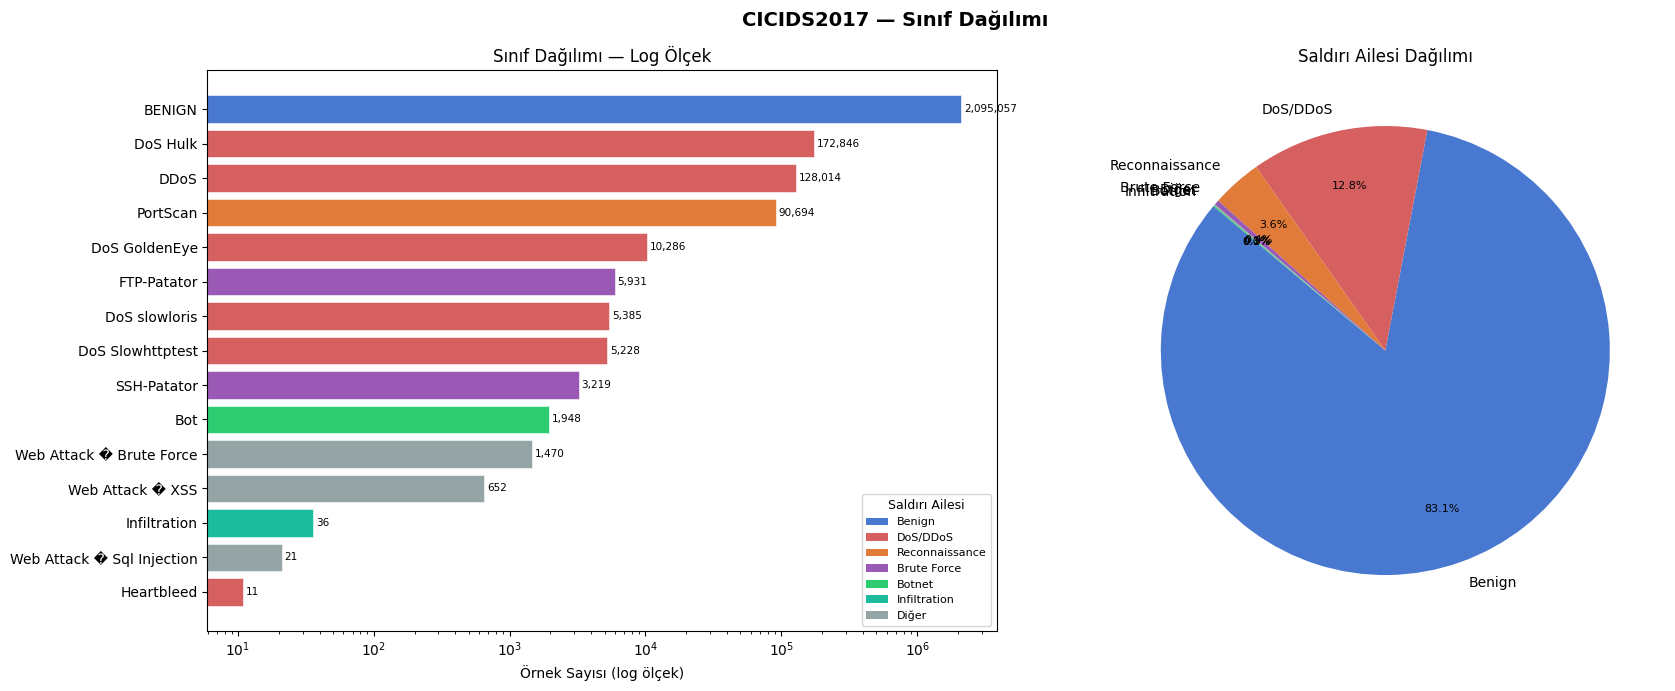

Kaydedildi → outputs/figures/sinif_dagilimi.png


In [19]:
### 4.4 Görselleştirme

FAMILY_PALETTE = {
    "Benign"        : "#4878CF",
    "DoS/DDoS"      : "#D65F5F",
    "Reconnaissance": "#E07B39",
    "Brute Force"   : "#9B59B6",
    "Web Attack"    : "#E8C03A",
    "Botnet"        : "#2ECC71",
    "Infiltration"  : "#1ABC9C",
    "Diğer"         : "#95A5A6",
}

label_family = df.drop_duplicates("Label").set_index("Label")["Family"]
colors = [FAMILY_PALETTE.get(label_family.get(lbl, "Diğer"), "#95A5A6")
          for lbl in class_counts.index]

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# ── Sol: Log-scale yatay bar ──────────────────────────────────────────────
axes[0].barh(class_counts.index[::-1], class_counts.values[::-1],
             color=colors[::-1], edgecolor="white", linewidth=0.4)
axes[0].set_xscale("log")
axes[0].set_xlabel("Örnek Sayısı (log ölçek)")
axes[0].set_title("Sınıf Dağılımı — Log Ölçek")
for i, (lbl, v) in enumerate(zip(class_counts.index[::-1], class_counts.values[::-1])):
    axes[0].text(v * 1.05, i, f"{v:,}", va="center", fontsize=7.5)

# Aile legendı
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=c, label=f) for f, c in FAMILY_PALETTE.items()
                   if f in label_family.values]
axes[0].legend(handles=legend_elements, title="Saldırı Ailesi",
               loc="lower right", fontsize=8, title_fontsize=9)

# ── Sağ: Aile bazlı pasta ─────────────────────────────────────────────────
fam_colors = [FAMILY_PALETTE.get(f, "#95A5A6") for f in family_counts.index]
wedges, texts, autotexts = axes[1].pie(
    family_counts.values,
    labels=family_counts.index,
    autopct="%1.1f%%",
    startangle=140,
    colors=fam_colors,
    pctdistance=0.75,
)
for t in autotexts:
    t.set_fontsize(8)
axes[1].set_title("Saldırı Ailesi Dağılımı")

plt.suptitle("CICIDS2017 — Sınıf Dağılımı", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(FIG_DIR / "sinif_dagilimi.png", dpi=150, bbox_inches="tight")
plt.show()
print("Kaydedildi → outputs/figures/sinif_dagilimi.png")

## 5. Eksik ve Sonsuz Değer Analizi

> Bu bölüm temizlik **öncesi** durumu raporlar; ham verinin sorunlarını belgelemek için tutulmaktadır.
> Temizlik adımları (3.4–3.6) zaten uygulandı; buradaki analizler referans niteliğindedir.

In [20]:
### 5.1 Temizlik sonrası NaN/∞ doğrulama

# Temizlik sonrası hiç NaN veya inf kalmamalı
nan_left = df[feature_cols].isna().sum().sum()
inf_left  = df[feature_cols].isin([np.inf, -np.inf]).sum().sum()

print(f"Kalan NaN : {nan_left}")
print(f"Kalan ∞   : {inf_left}")

if nan_left == 0 and inf_left == 0:
    print("\n✓ Temiz — devam edilebilir.")
else:
    print("\n⚠ Temizlenmemiş değerler var, temizlik hücrelerini yeniden çalıştır.")

Kalan NaN : 0
Kalan ∞   : 0

✓ Temiz — devam edilebilir.


In [21]:
### 5.2 Sonsuz değerlerin sınıf dağılımı

# Ham CSV'lerde hangi sınıflarda ∞ değer yoğunlaşıyordu?
# (Bu analiz için ham verileri yeniden okumak yerine temizlik logunu yeniden üretelim)
# Flow Bytes/s ve Flow Packets/s'de ∞, sıfır süreli akışlarda (duration=0) oluşur.

zero_dur = df["Flow Duration"] == 0
print(f"Flow Duration = 0 olan satır: {zero_dur.sum():,}  ({zero_dur.sum()/len(df)*100:.3f}%)")
print("\nBu satırlarda sınıf dağılımı:")
print(df.loc[zero_dur, "Label"].value_counts().to_string())

print("\nAçıklama: duration=0 → Bytes/s ve Packets/s = n/0 → CICFlowMeter'da ∞ üretilir.")
print("Temizlik adımında bu satırlar inf→NaN→dropna ile zaten düşürüldü.")

Flow Duration = 0 olan satır: 107  (0.004%)

Bu satırlarda sınıf dağılımı:
Label
BENIGN    107

Açıklama: duration=0 → Bytes/s ve Packets/s = n/0 → CICFlowMeter'da ∞ üretilir.
Temizlik adımında bu satırlar inf→NaN→dropna ile zaten düşürüldü.


In [22]:
### 5.3 Özellik başına istatistik özeti (min / max / skewness)

desc = df[feature_cols].describe().T
desc["skewness"] = df[feature_cols].skew().round(3)
desc["missing%"] = (df[feature_cols].isna().sum() / len(df) * 100).round(4)

# Aşırı çarpık (|skew| > 10) özellikler
high_skew = desc[desc["skewness"].abs() > 10]["skewness"].sort_values(key=abs, ascending=False)
print(f"|skewness| > 10 olan özellik sayısı: {len(high_skew)}")
print(high_skew.to_string())

print("\nGenel istatistik (ilk 10 özellik):")
desc[["mean", "std", "min", "max", "skewness"]].head(10)

|skewness| > 10 olan özellik sayısı: 25
Total Length of Fwd Packets   760.5810
Subflow Fwd Bytes             758.7210
act_data_pkt_fwd              268.5640
Subflow Bwd Packets           230.8970
Total Backward Packets        230.8970
Total Fwd Packets             230.6150
Subflow Fwd Packets           230.6150
Subflow Bwd Bytes             230.5710
Total Length of Bwd Packets   230.5670
Fwd Header Length             229.8000
Bwd Header Length             229.7580
CWE Flag Count                177.5020
Fwd URG Flags                 177.5020
RST Flag Count                 60.5940
ECE Flag Count                 60.4620
Flow Bytes/s                   45.6770
Active Min                     45.0480
Active Std                     38.2330
Active Mean                    36.1420
Flow IAT Min                   23.4820
Active Max                     23.0230
Bwd Packets/s                  21.7070
Fwd Packet Length Min          19.3310
Down/Up Ratio                  12.5730
Min Packet Length       

,mean,std,min,max,skewness
Destination Port,8690.5904,19012.8006,0.0000,65535.0000,1.9340
Flow Duration,16591611.4640,35232762.9303,0.0000,119999998.0000,1.9640
Total Fwd Packets,10.2817,794.4201,1.0000,219759.0000,230.6150
Total Backward Packets,11.5728,1056.9221,0.0000,291922.0000,230.8970
Total Length of Fwd Packets,611.9477,10588.2670,0.0000,12900000.0000,760.5810
Total Length of Bwd Packets,18144.4025,2398177.3951,0.0000,655453030.0000,230.5670
Fwd Packet Length Max,231.2292,756.3755,0.0000,24820.0000,9.3360
Fwd Packet Length Min,19.2035,60.7983,0.0000,2325.0000,19.3310
Fwd Packet Length Mean,63.5050,195.5526,0.0000,5940.8571,8.6840
Fwd Packet Length Std,77.3235,296.8814,0.0000,7125.5968,9.9640


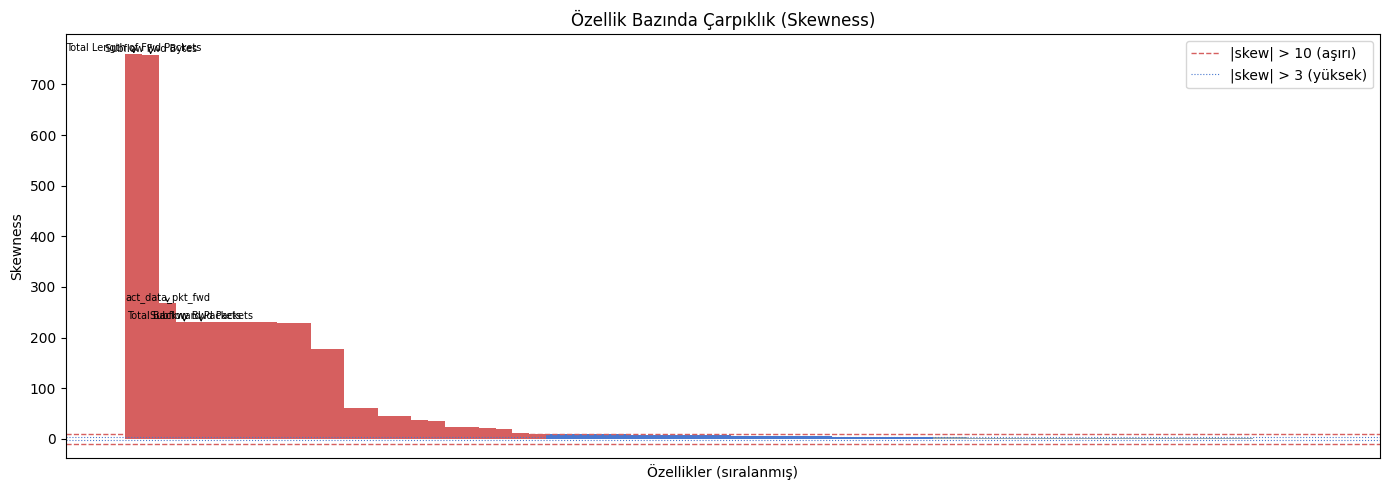

Kaydedildi → outputs/figures/skewness_dagilimi.png


In [23]:
### 5.4 Aşırı çarpıklık görselleştirmesi

fig, ax = plt.subplots(figsize=(14, 5))

skew_vals = df[feature_cols].skew().sort_values(ascending=False)
colors_skew = ["#D65F5F" if abs(v) > 10 else "#4878CF" if abs(v) > 3 else "#95A5A6"
               for v in skew_vals]

ax.bar(range(len(skew_vals)), skew_vals.values, color=colors_skew, width=1.0)
ax.axhline(10,  color="#D65F5F", lw=1, ls="--", label="|skew| > 10 (aşırı)")
ax.axhline(-10, color="#D65F5F", lw=1, ls="--")
ax.axhline(3,   color="#4878CF", lw=0.8, ls=":", label="|skew| > 3 (yüksek)")
ax.axhline(-3,  color="#4878CF", lw=0.8, ls=":")
ax.set_xticks([])
ax.set_xlabel("Özellikler (sıralanmış)")
ax.set_ylabel("Skewness")
ax.set_title("Özellik Bazında Çarpıklık (Skewness)")
ax.legend()

# En aşırı 5 özelliği etiketle
top5_idx = skew_vals.abs().nlargest(5).index
for feat in top5_idx:
    i = skew_vals.index.get_loc(feat)
    ax.annotate(feat, xy=(i, skew_vals[feat]),
                xytext=(i, skew_vals[feat] + 5),
                fontsize=7, ha="center",
                arrowprops=dict(arrowstyle="->", lw=0.7))

plt.tight_layout()
plt.savefig(FIG_DIR / "skewness_dagilimi.png", dpi=150, bbox_inches="tight")
plt.show()
print("Kaydedildi → outputs/figures/skewness_dagilimi.png")

In [24]:
### 5.5 Sonuç özeti

print("=" * 60)
print("  EKSİK / SONSUZ DEĞER ANALİZİ — ÖZET")
print("=" * 60)
print(f"  Temizlik sonrası kalan NaN      : {df[feature_cols].isna().sum().sum()}")
print(f"  Temizlik sonrası kalan ∞        : {df[feature_cols].isin([np.inf,-np.inf]).sum().sum()}")
print(f"  |skewness| > 10 özellik sayısı : {(df[feature_cols].skew().abs() > 10).sum()}")
print(f"  |skewness| > 3  özellik sayısı : {(df[feature_cols].skew().abs() > 3).sum()}")
print()
print("  NOT: Aşırı çarpık özellikler Faz 2 pipeline'ında")
print("  StandardScaler öncesi log1p dönüşümüne aday.")
print("=" * 60)

  EKSİK / SONSUZ DEĞER ANALİZİ — ÖZET
  Temizlik sonrası kalan NaN      : 0
  Temizlik sonrası kalan ∞        : 0
  |skewness| > 10 özellik sayısı : 25
  |skewness| > 3  özellik sayısı : 48

  NOT: Aşırı çarpık özellikler Faz 2 pipeline'ında
  StandardScaler öncesi log1p dönüşümüne aday.


## 6. Korelasyon Isı Haritası

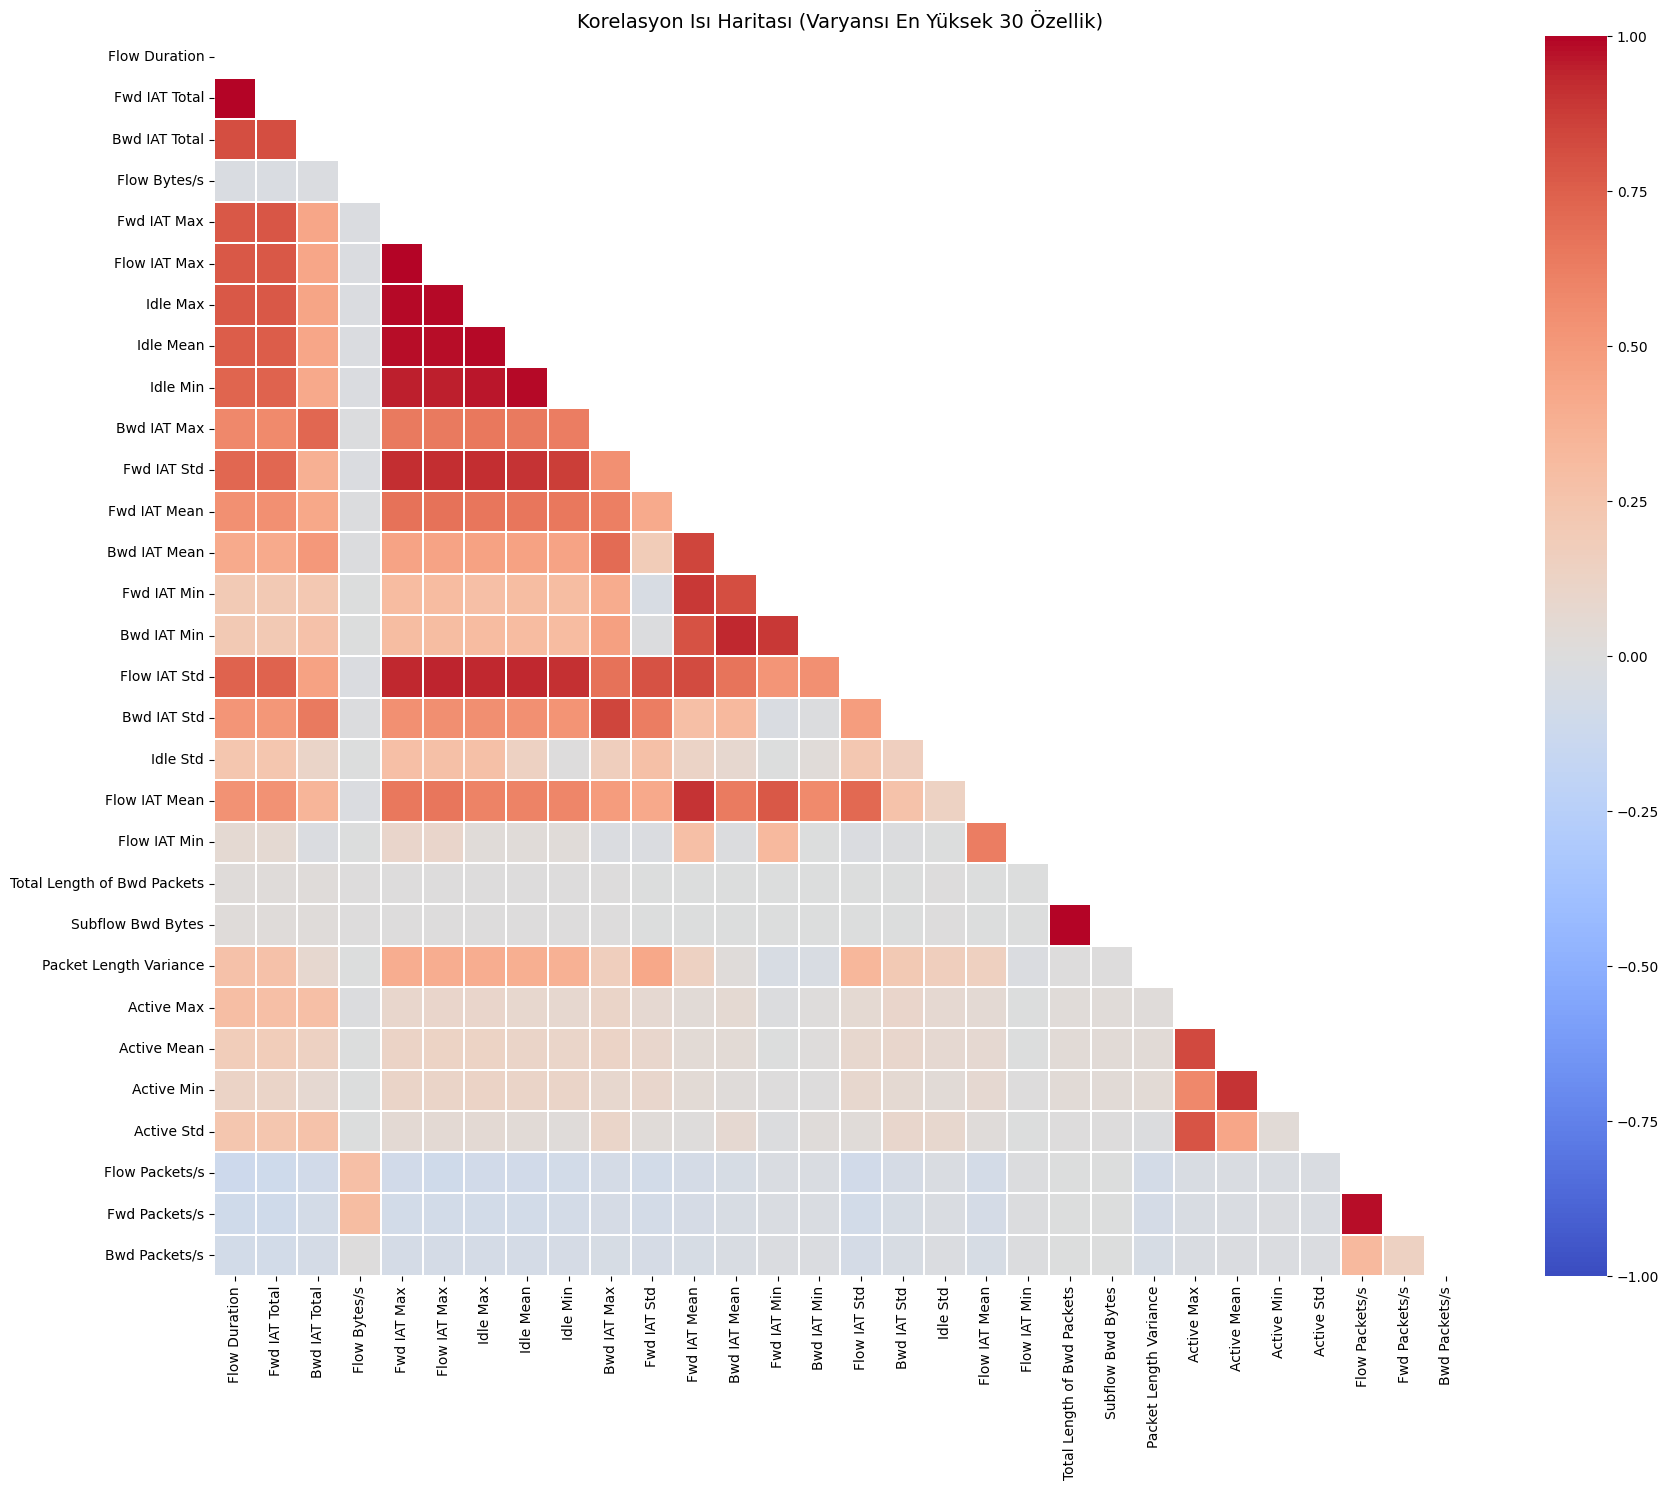

Kaydedildi → outputs/figures/korelasyon.png


In [25]:
# 79 özellik çok kalabalık olur; varyansı en yüksek 30 özelliği seç
top30 = df[feature_cols].var().nlargest(30).index.tolist()
corr = df[top30].corr()

fig, ax = plt.subplots(figsize=(18, 15))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr,
    mask=mask,
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.3,
    annot=False,
    ax=ax,
)
ax.set_title("Korelasyon Isı Haritası (Varyansı En Yüksek 30 Özellik)", fontsize=14)
plt.tight_layout()
plt.savefig(FIG_DIR / "korelasyon.png", dpi=150, bbox_inches="tight")
plt.show()
print("Kaydedildi → outputs/figures/korelasyon.png")

## 7. Yüksek Korelasyonlu Çiftler (|r| ≥ 0.95)

In [26]:
### 7.1 Korelasyon matrisini hesapla ve yüksek çiftleri bul

corr_matrix = df[feature_cols].corr()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

high_corr = (
    upper.stack()
    .reset_index()
    .rename(columns={"level_0": "Özellik A", "level_1": "Özellik B", 0: "r"})
)
high_corr["|r|"] = high_corr["r"].abs()
high_corr = (
    high_corr[high_corr["|r|"] >= 0.95]
    .sort_values("|r|", ascending=False)
    .reset_index(drop=True)
)

print(f"|r| ≥ 0.95 olan çift sayısı: {len(high_corr)}")
print(f"|r| ≥ 0.99 olan çift sayısı: {(high_corr['|r|'] >= 0.99).sum()}")
print(f"|r| = 1.00 olan çift sayısı: {(high_corr['|r|'] == 1.0).sum()}  ← mükemmel kopya\n")
high_corr.head(30)

|r| ≥ 0.95 olan çift sayısı: 51
|r| ≥ 0.99 olan çift sayısı: 39
|r| = 1.00 olan çift sayısı: 5  ← mükemmel kopya



,Özellik A,Özellik B,r,|r|
0,Bwd Packet Length Mean,Avg Bwd Segment Size,1.0000,1.0000
1,Total Fwd Packets,Subflow Fwd Packets,1.0000,1.0000
2,Fwd PSH Flags,SYN Flag Count,1.0000,1.0000
3,Fwd URG Flags,CWE Flag Count,1.0000,1.0000
4,Total Backward Packets,Subflow Bwd Packets,1.0000,1.0000
5,Fwd Packet Length Mean,Avg Fwd Segment Size,1.0000,1.0000
6,Total Length of Bwd Packets,Subflow Bwd Bytes,1.0000,1.0000
7,Total Length of Fwd Packets,Subflow Fwd Bytes,1.0000,1.0000
8,Total Backward Packets,Bwd Header Length,0.9996,0.9996
9,Bwd Header Length,Subflow Bwd Packets,0.9996,0.9996


In [28]:
### 7.2 Çıkarılacak sütunları belirle (greedy seçim)

# Bir sütun birden fazla yüksek korelasyonlu çiftte yer alıyorsa
# en fazla çiftte geçen sütunu çıkar (greedy — en az bilgi kaybı).

from collections import Counter

THRESHOLD = 0.95

# Hangi sütunlar kaç farklı yüksek-korelasyon çiftinde geçiyor?
all_feat = list(high_corr["Özellik A"]) + list(high_corr["Özellik B"])
freq = Counter(all_feat)

to_drop = set()
for _, row in high_corr.iterrows():
    a, b = row["Özellik A"], row["Özellik B"]
    if a in to_drop or b in to_drop:
        continue
    # Daha fazla çiftte geçeni çıkar; eşitse B'yi çıkar
    if freq[a] >= freq[b]:
        to_drop.add(a)
    else:
        to_drop.add(b)

print(f"Çıkarılacak sütun sayısı : {len(to_drop)}")
print(f"Kalan özellik sayısı     : {len(feature_cols) - len(to_drop)}")
print("\nÇıkarılacak sütunlar:")
for col in sorted(to_drop):
    print(f"  {col}")

Çıkarılacak sütun sayısı : 22
Kalan özellik sayısı     : 49

Çıkarılacak sütunlar:
  Bwd Header Length
  Bwd Packet Length Max
  Bwd Packet Length Mean
  Flow Duration
  Flow IAT Max
  Flow Packets/s
  Fwd Header Length
  Fwd PSH Flags
  Fwd Packet Length Max
  Fwd Packet Length Mean
  Fwd URG Flags
  Idle Max
  Idle Mean
  Max Packet Length
  Packet Length Mean
  RST Flag Count
  Subflow Bwd Packets
  Subflow Fwd Packets
  Total Backward Packets
  Total Fwd Packets
  Total Length of Bwd Packets
  Total Length of Fwd Packets


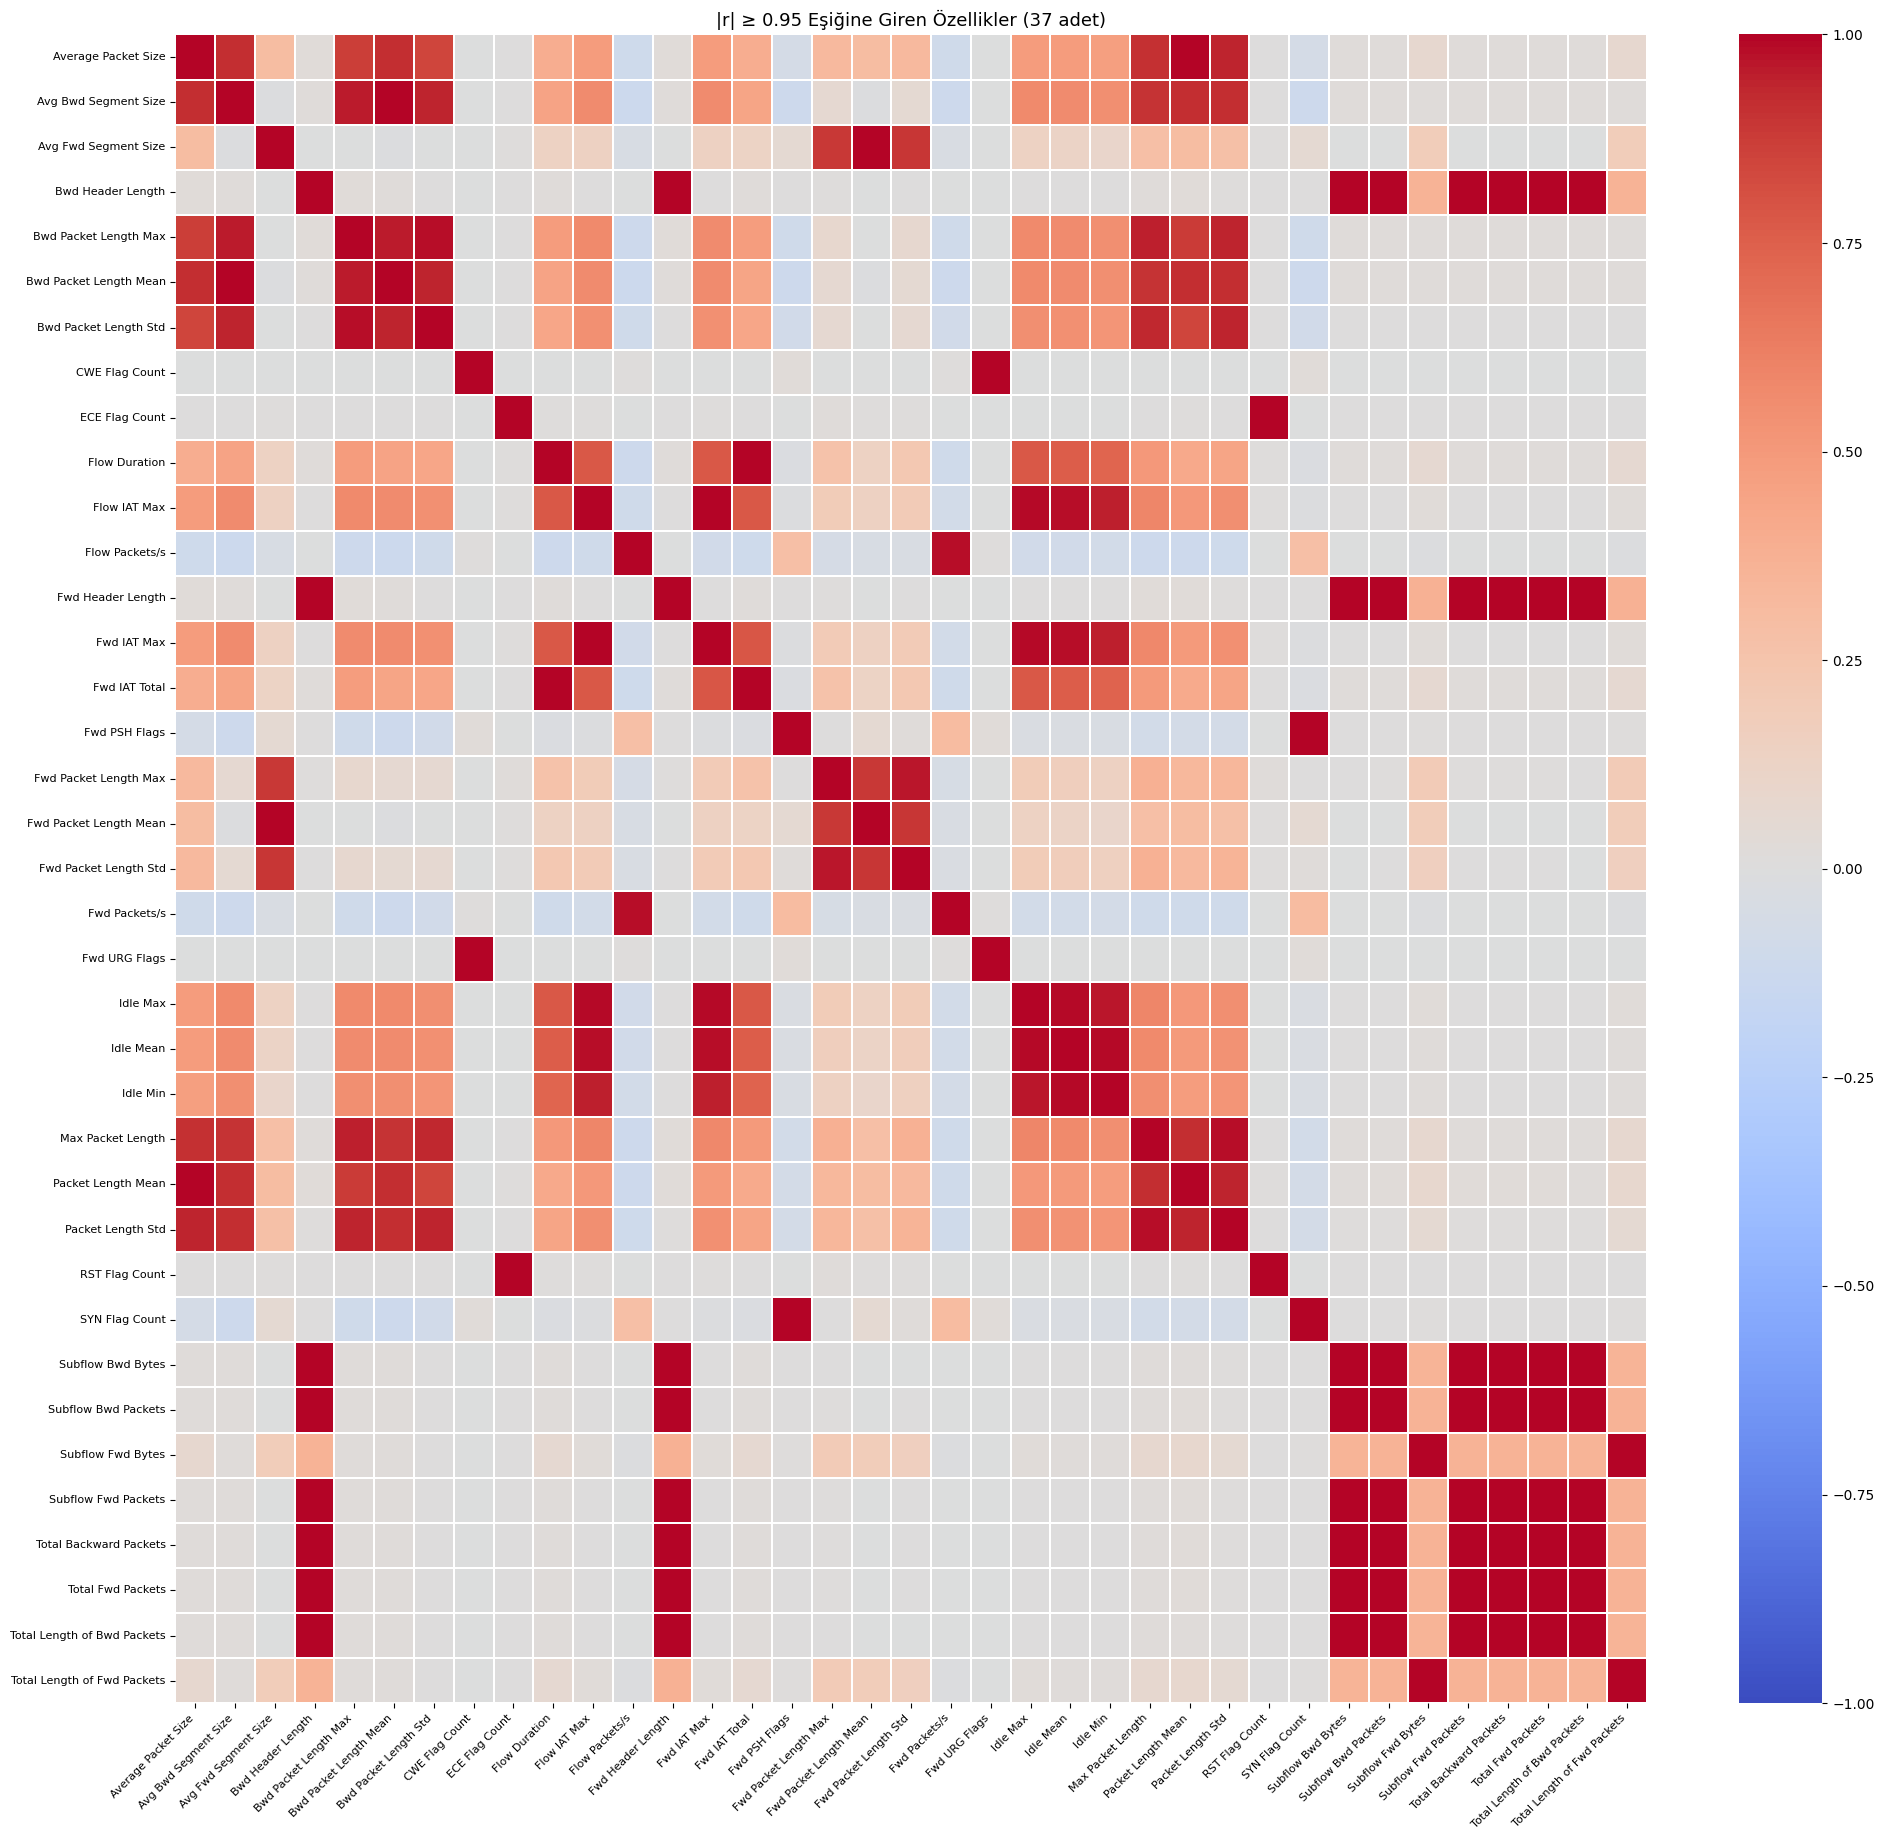

Kaydedildi → outputs/figures/yuksek_korelasyon.png


In [29]:
### 7.3 Yüksek korelasyon ısı haritası (|r| ≥ 0.95 olan sütunlar)

# Sadece en az bir yüksek korelasyonlu çiftte geçen sütunları göster
involved = sorted(set(high_corr["Özellik A"]) | set(high_corr["Özellik B"]))
sub_corr = corr_matrix.loc[involved, involved]

fig, ax = plt.subplots(figsize=(max(10, len(involved) * 0.55),
                                max(8,  len(involved) * 0.5)))
sns.heatmap(
    sub_corr,
    cmap="coolwarm",
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.3,
    annot=len(involved) <= 20,   # 20'den az ise değerleri yaz
    fmt=".2f",
    annot_kws={"size": 7},
    ax=ax,
)
ax.set_title(f"|r| ≥ {THRESHOLD} Eşiğine Giren Özellikler ({len(involved)} adet)", fontsize=13)
plt.xticks(rotation=45, ha="right", fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.savefig(FIG_DIR / "yuksek_korelasyon.png", dpi=150, bbox_inches="tight")
plt.show()
print("Kaydedildi → outputs/figures/yuksek_korelasyon.png")

In [30]:
### 7.4 Listeyi kaydet — Faz 4'te kullanılacak

import json

corr_drop_info = {
    "threshold"  : THRESHOLD,
    "pairs_found": len(high_corr),
    "to_drop"    : sorted(to_drop),
    "to_keep"    : sorted(set(feature_cols) - to_drop),
}

out_path = Path("../outputs/results")
out_path.mkdir(parents=True, exist_ok=True)
with open(out_path / "high_corr_to_drop.json", "w") as f:
    json.dump(corr_drop_info, f, indent=2, ensure_ascii=False)

high_corr.to_csv(out_path / "high_corr_pairs.csv", index=False)

print(f"Kaydedildi → outputs/results/high_corr_pairs.csv")
print(f"Kaydedildi → outputs/results/high_corr_to_drop.json")
print(f"\nNOT: Bu bölüm sadece tespit yapar; sütunlar henüz düşürülmedi.")
print(f"Faz 4 (Feature Engineering) bu listeyi kullanarak eleme yapacak.")

Kaydedildi → outputs/results/high_corr_pairs.csv
Kaydedildi → outputs/results/high_corr_to_drop.json

NOT: Bu bölüm sadece tespit yapar; sütunlar henüz düşürülmedi.
Faz 4 (Feature Engineering) bu listeyi kullanarak eleme yapacak.


## 8. Özellik Dağılımları — Sınıfa Göre Karşılaştırma

In [31]:
### 8.1 Ayırt edici özellik sıralaması (ANOVA F-skoru)

# Medyan farkı yerine ANOVA F-skoru kullan:
# yüksek F → sınıflar arası varyans / sınıf içi varyans büyük → iyi ayırt edici
from sklearn.feature_selection import f_classif
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_enc = le.fit_transform(df["Label"])

F_scores, p_values = f_classif(df[feature_cols], y_enc)

f_rank = (
    pd.DataFrame({"Özellik": feature_cols, "F": F_scores, "p": p_values})
    .sort_values("F", ascending=False)
    .reset_index(drop=True)
)

print("En ayırt edici 20 özellik (ANOVA F-skoru):")
print(f_rank.head(20).to_string(index=False))

TOP_N = 12  # görselleştirme için
top_features = f_rank.head(TOP_N)["Özellik"].tolist()

En ayırt edici 20 özellik (ANOVA F-skoru):
               Özellik           F      p
           Fwd IAT Std 244436.5457 0.0000
 Bwd Packet Length Std 238331.9051 0.0000
Bwd Packet Length Mean 237250.2438 0.0000
  Avg Bwd Segment Size 237250.2438 0.0000
 Bwd Packet Length Max 227096.5054 0.0000
              Idle Min 201148.4438 0.0000
             Idle Mean 199892.6100 0.0000
     Packet Length Std 194438.0227 0.0000
              Idle Max 185697.7412 0.0000
          Flow IAT Max 179270.0384 0.0000
           Fwd IAT Max 178271.2346 0.0000
     Max Packet Length 175612.2093 0.0000
   Average Packet Size 153832.8048 0.0000
    Packet Length Mean 151901.4069 0.0000
Packet Length Variance 142491.6406 0.0000
          Flow IAT Std 109969.1218 0.0000
         Fwd IAT Total  53049.2120 0.0000
        FIN Flag Count  52614.3242 0.0000
         Flow Duration  52361.1665 0.0000
           Bwd IAT Std  28315.7355 0.0000


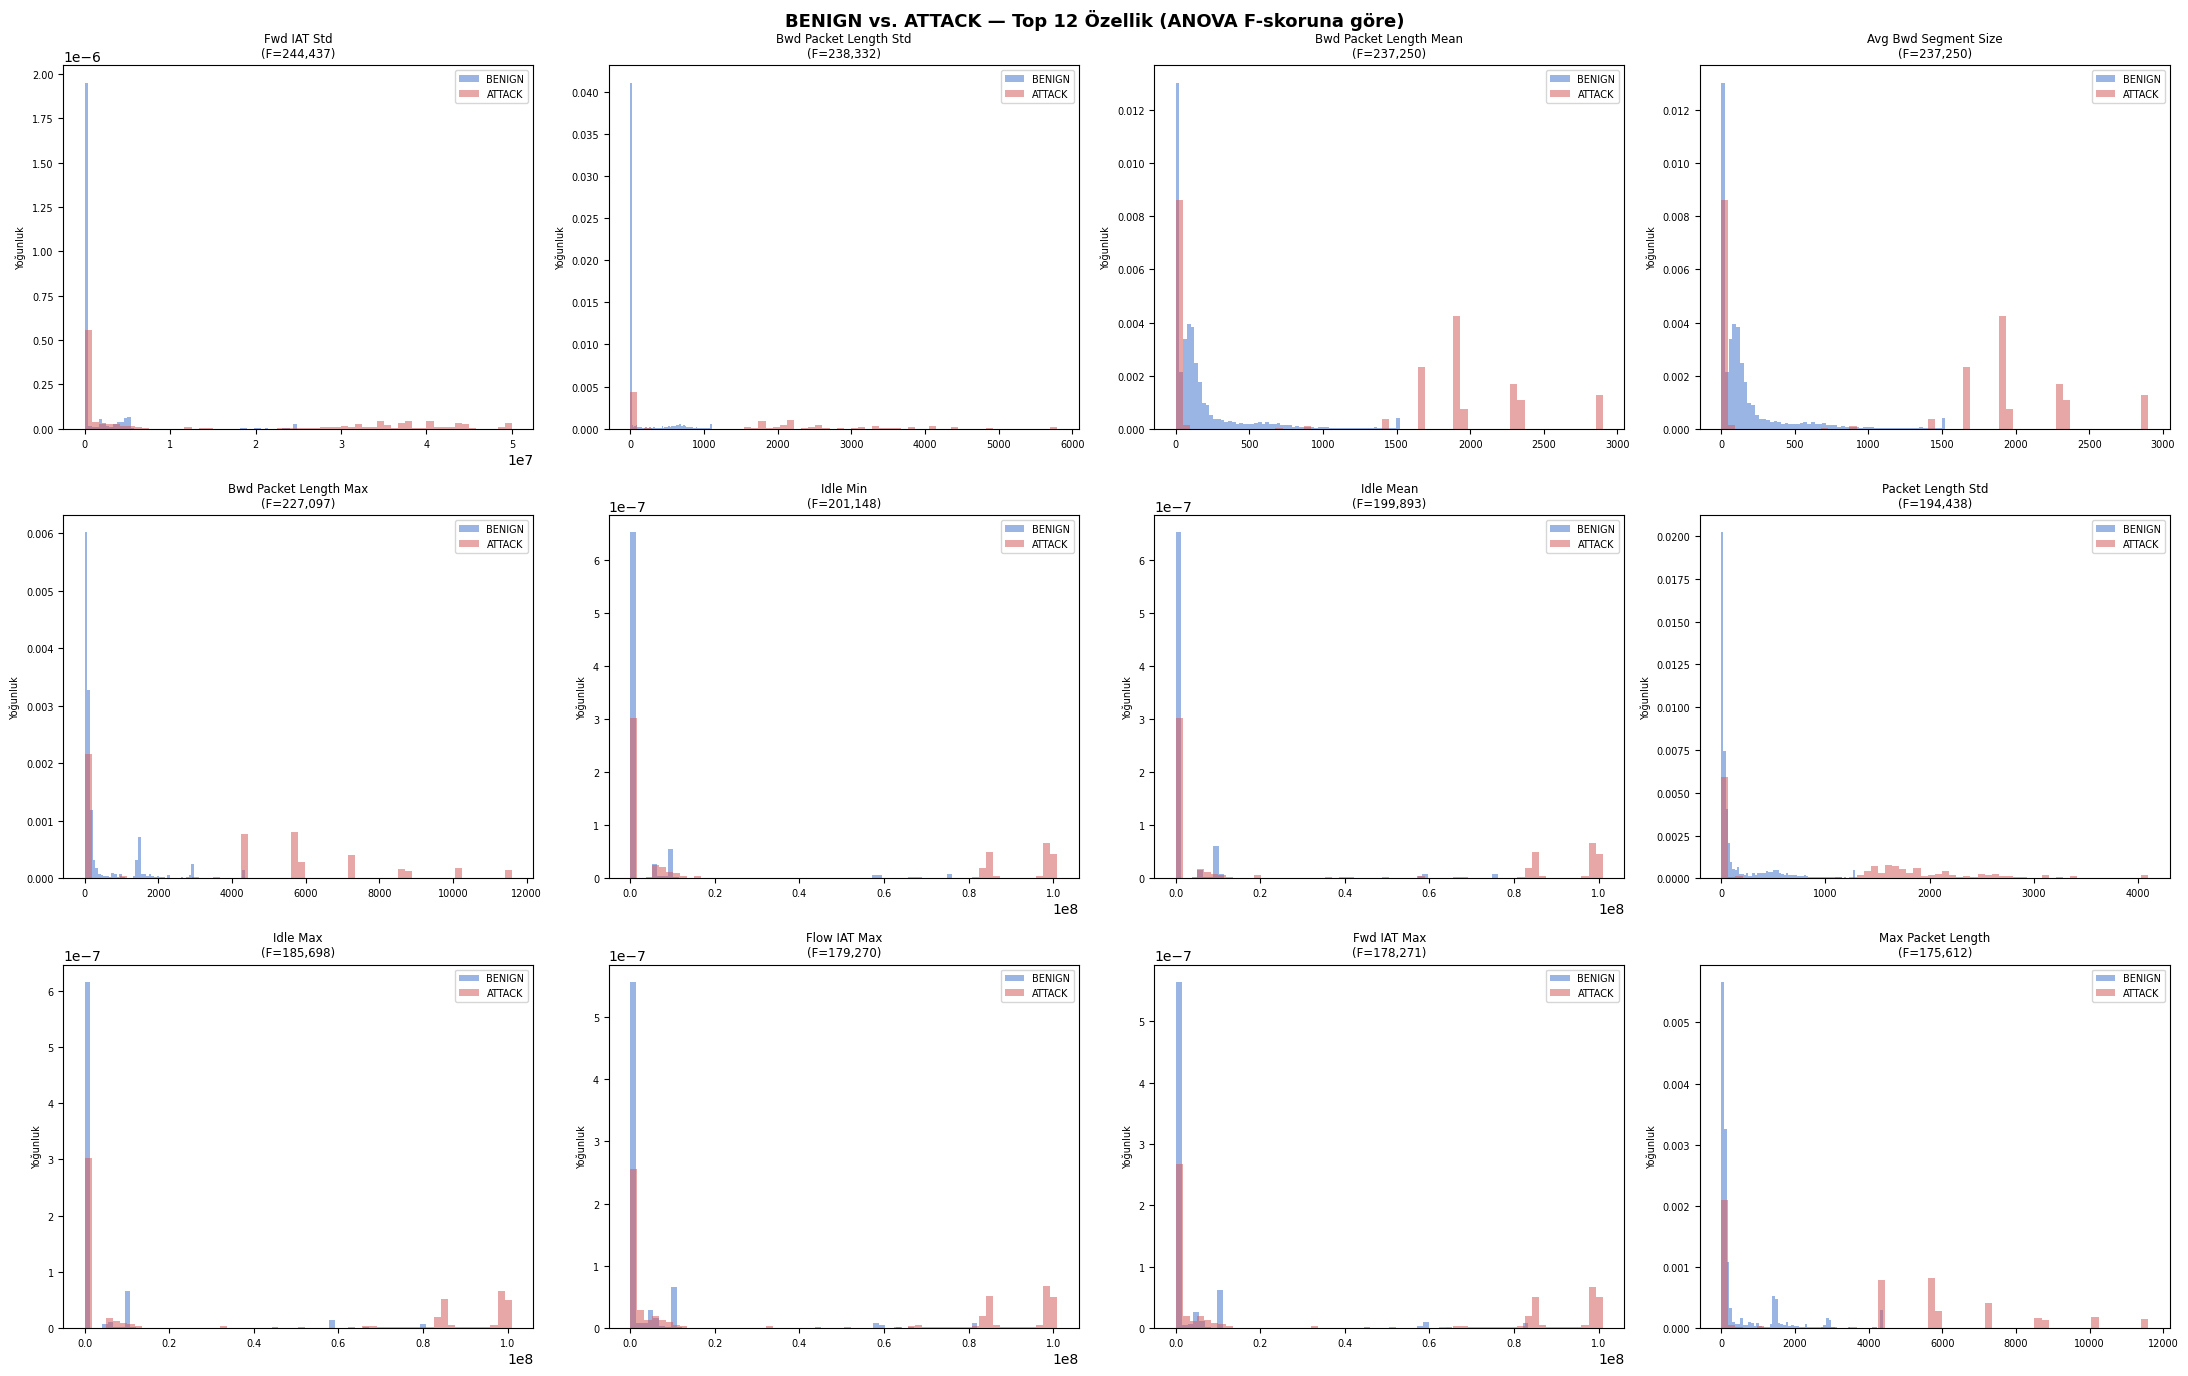

Kaydedildi → outputs/figures/ozellik_dagilim_binary.png


In [32]:
### 8.2 BENIGN vs. ATTACK — Histogram karşılaştırması (Top 12)

fig, axes = plt.subplots(3, 4, figsize=(22, 14))
axes = axes.flatten()

# Örnekle — 2M+ satır histogram çizmek için yavaş olabilir
SAMPLE = 200_000
df_sample = df.sample(min(SAMPLE, len(df)), random_state=42)
binary_groups = {
    "BENIGN": df_sample[df_sample["Label"] == "BENIGN"],
    "ATTACK": df_sample[df_sample["Label"] != "BENIGN"],
}
COLORS = {"BENIGN": "#4878CF", "ATTACK": "#D65F5F"}

for i, feat in enumerate(top_features):
    ax = axes[i]
    for label, grp in binary_groups.items():
        vals = grp[feat].clip(upper=grp[feat].quantile(0.99))
        ax.hist(vals, bins=60, alpha=0.55, label=label,
                color=COLORS[label], density=True)
    ax.set_title(f"{feat}\n(F={f_rank.loc[f_rank['Özellik']==feat,'F'].values[0]:,.0f})",
                 fontsize=8.5)
    ax.set_ylabel("Yoğunluk", fontsize=7)
    ax.tick_params(labelsize=7)
    ax.legend(fontsize=7)

# Kullanılmayan eksenleri gizle
for j in range(len(top_features), len(axes)):
    axes[j].set_visible(False)

plt.suptitle("BENIGN vs. ATTACK — Top 12 Özellik (ANOVA F-skoruna göre)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(FIG_DIR / "ozellik_dagilim_binary.png", dpi=150, bbox_inches="tight")
plt.show()
print("Kaydedildi → outputs/figures/ozellik_dagilim_binary.png")

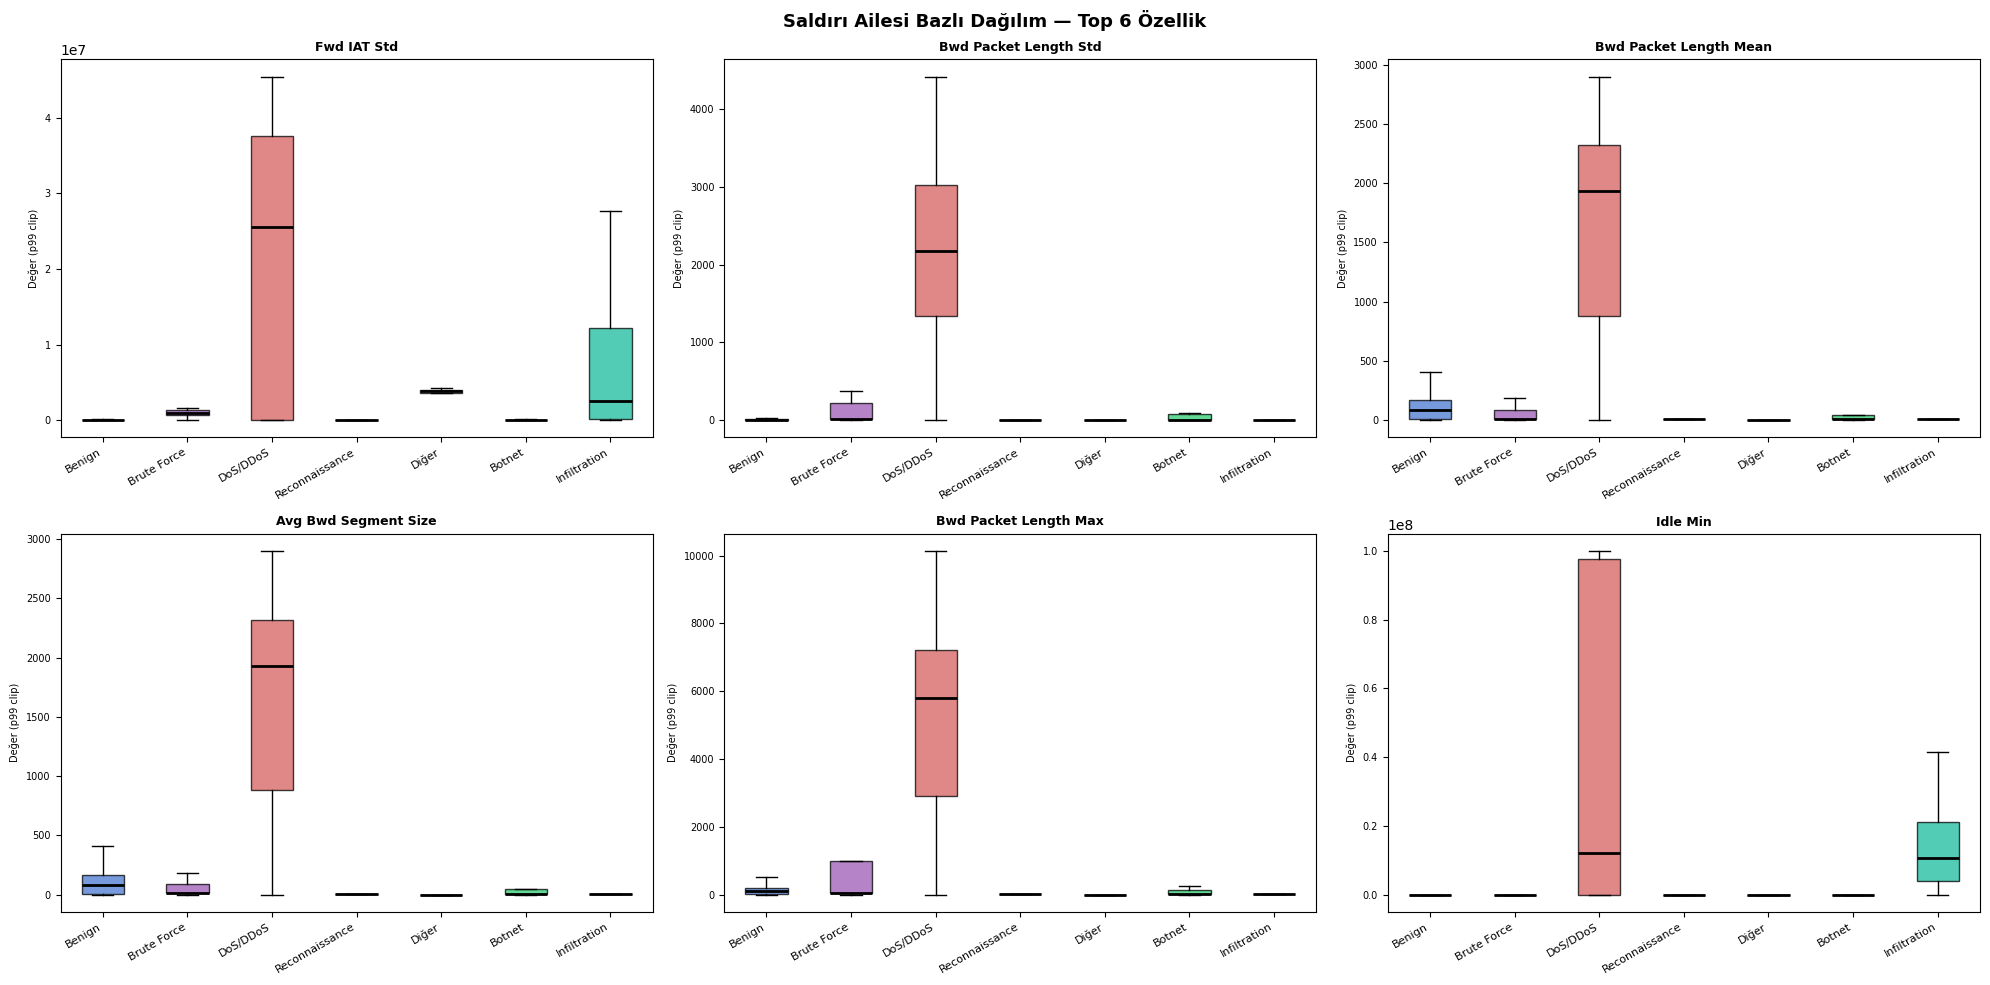

Kaydedildi → outputs/figures/ozellik_dagilim_aile.png


In [33]:
### 8.3 Saldırı ailesi bazlı box plot (Top 6 özellik)

top6 = top_features[:6]

# Küçük örnekle — her aileden en fazla 5000 satır al
df_box = (
    df.groupby("Family", group_keys=False)
    .apply(lambda x: x.sample(min(5000, len(x)), random_state=42))
)

fig, axes = plt.subplots(2, 3, figsize=(20, 10))
axes = axes.flatten()

fam_order = df_box["Family"].value_counts().index.tolist()
fam_colors_list = [FAMILY_PALETTE.get(f, "#95A5A6") for f in fam_order]

for i, feat in enumerate(top6):
    ax = axes[i]
    data_by_fam = [df_box.loc[df_box["Family"] == f, feat]
                          .clip(upper=df_box[feat].quantile(0.99))
                   for f in fam_order]
    bp = ax.boxplot(data_by_fam, patch_artist=True, showfliers=False,
                    medianprops=dict(color="black", lw=2))
    for patch, color in zip(bp["boxes"], fam_colors_list):
        patch.set_facecolor(color)
        patch.set_alpha(0.75)
    ax.set_xticklabels(fam_order, rotation=30, ha="right", fontsize=8)
    ax.set_title(feat, fontsize=9, fontweight="bold")
    ax.set_ylabel("Değer (p99 clip)", fontsize=7)
    ax.tick_params(axis="y", labelsize=7)

plt.suptitle("Saldırı Ailesi Bazlı Dağılım — Top 6 Özellik",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(FIG_DIR / "ozellik_dagilim_aile.png", dpi=150, bbox_inches="tight")
plt.show()
print("Kaydedildi → outputs/figures/ozellik_dagilim_aile.png")

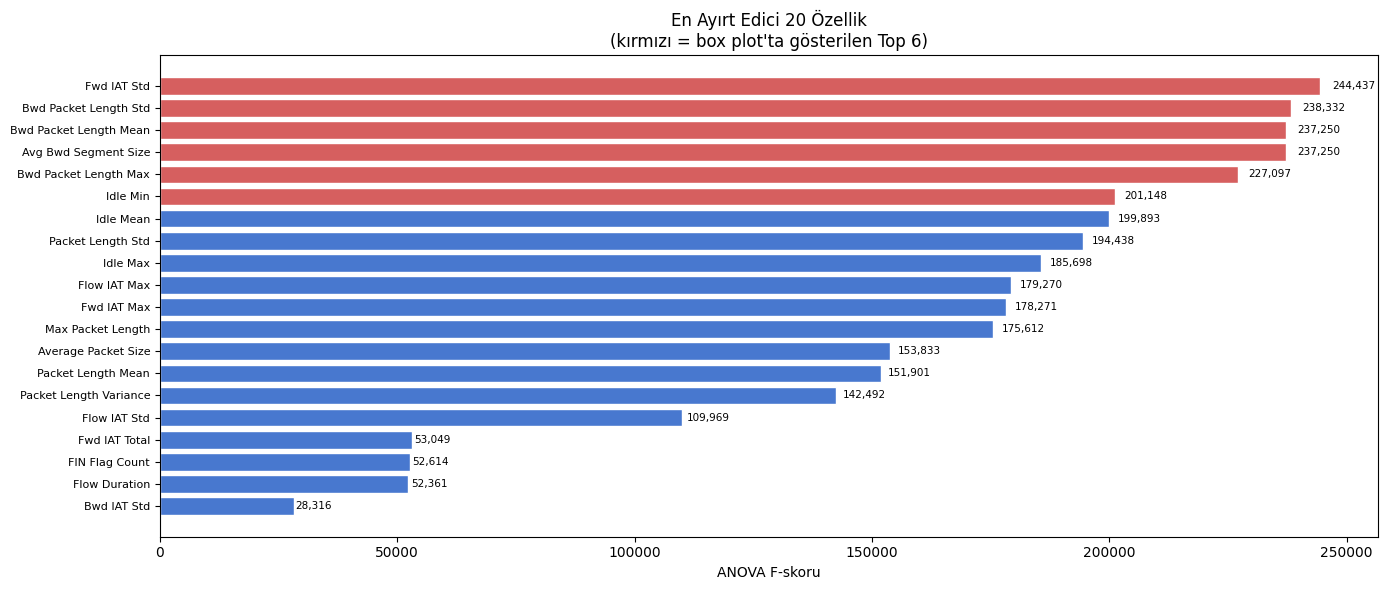

Kaydedildi → outputs/figures/f_skoru_siralaması.png
Kaydedildi → outputs/results/feature_f_scores.csv


In [34]:
### 8.4 F-skoru sıralaması bar grafiği (tüm özellikler)

fig, ax = plt.subplots(figsize=(14, 6))

top20 = f_rank.head(20)
bar_colors = ["#D65F5F" if f in top6 else "#4878CF" for f in top20["Özellik"]]

ax.barh(top20["Özellik"][::-1], top20["F"][::-1],
        color=bar_colors[::-1], edgecolor="white")
ax.set_xlabel("ANOVA F-skoru")
ax.set_title("En Ayırt Edici 20 Özellik\n(kırmızı = box plot'ta gösterilen Top 6)")
ax.tick_params(axis="y", labelsize=8)

for i, (feat, fval) in enumerate(zip(top20["Özellik"][::-1], top20["F"][::-1])):
    ax.text(fval * 1.01, i, f"{fval:,.0f}", va="center", fontsize=7.5)

plt.tight_layout()
plt.savefig(FIG_DIR / "f_skoru_siralaması.png", dpi=150, bbox_inches="tight")
plt.show()

# Sonuçları kaydet
f_rank.to_csv(Path("../outputs/results") / "feature_f_scores.csv", index=False)
print("Kaydedildi → outputs/figures/f_skoru_siralaması.png")
print("Kaydedildi → outputs/results/feature_f_scores.csv")

## 9. Temizlenmiş Veriyi Kaydet

In [35]:
### 9.1 Son kontrol — kaydedilecek DataFrame doğrulama

# EDA'da eklenen geçici sütunları temizle (Family, BinaryLabel varsa)
TEMP_COLS = ["Family", "BinaryLabel"]
df_clean = df.drop(columns=[c for c in TEMP_COLS if c in df.columns])

# feature_cols'u güncelle
feat_final = [c for c in df_clean.columns if c != "Label"]

assert df_clean["Label"].isna().sum() == 0,       "Label'da NaN var!"
assert df_clean[feat_final].isna().sum().sum() == 0, "Feature'larda NaN var!"
assert df_clean[feat_final].isin([np.inf, -np.inf]).sum().sum() == 0, "∞ var!"

print("✓ NaN   : 0")
print("✓ ∞     : 0")
print(f"✓ Boyut : {df_clean.shape[0]:,} satır × {df_clean.shape[1]} sütun")
print(f"✓ Sınıf : {df_clean['Label'].nunique()} benzersiz etiket")
print(f"✓ Özellik sütunları: {len(feat_final)}")
print(f"  — orijinal 79'a göre fark: {len(feat_final) - 79:+d}")

✓ NaN   : 0
✓ ∞     : 0
✓ Boyut : 2,520,798 satır × 72 sütun
✓ Sınıf : 15 benzersiz etiket
✓ Özellik sütunları: 71
  — orijinal 79'a göre fark: -8


In [36]:
### 9.2 Veriyi kaydet

OUT_DATA = Path("../outputs")
OUT_DATA.mkdir(exist_ok=True)

parquet_path = OUT_DATA / "cicids2017_clean.parquet"
csv_path     = OUT_DATA / "cicids2017_clean.csv.gz"

saved_as = None

# Parquet tercih (pyarrow session başından beri yüklüyse çalışır)
try:
    import pyarrow  # noqa: F401
    df_clean.to_parquet(parquet_path, index=False, engine="pyarrow", compression="snappy")
    size_mb = parquet_path.stat().st_size / 1024 / 1024
    print(f"✓ Parquet kaydedildi → {parquet_path}  ({size_mb:.1f} MB)")

    df_verify = pd.read_parquet(parquet_path)
    assert df_verify.shape == df_clean.shape
    print("✓ Bütünlük testi geçti.")
    saved_as = "parquet"

except Exception as e:
    print(f"⚠ Parquet başarısız ({type(e).__name__}): {e}")
    print("  → gzip CSV'ye düşülüyor (kernel yeniden başlatıldığında parquet çalışır)...")
    df_clean.to_csv(csv_path, index=False, compression="gzip")
    size_mb = csv_path.stat().st_size / 1024 / 1024
    print(f"✓ CSV.gz kaydedildi → {csv_path}  ({size_mb:.1f} MB)")
    saved_as = "csv.gz"

print(f"\nKayıt formatı : {saved_as}")
print(f"Satır sayısı  : {len(df_clean):,}")

✓ Parquet kaydedildi → ../outputs/cicids2017_clean.parquet  (303.2 MB)
✓ Bütünlük testi geçti.

Kayıt formatı : parquet
Satır sayısı  : 2,520,798


In [37]:
### 9.3 Sütun manifestosu kaydet

# Sonraki fazlar hangi sütunların ne anlama geldiğini bilmeli
import json

manifest = {
    "total_rows"       : int(len(df_clean)),
    "total_cols"       : int(df_clean.shape[1]),
    "label_col"        : "Label",
    "feature_cols"     : feat_final,
    "sentinel_flags"   : ["tcp_win_seen_forward", "tcp_win_seen_backward"],
    "classes"          : df_clean["Label"].value_counts().to_dict(),
    "high_corr_candidates_to_drop": sorted(to_drop),  # Faz 4'te uygulanacak
}

manifest_path = OUT_DATA / "dataset_manifest.json"
with open(manifest_path, "w", encoding="utf-8") as f:
    json.dump(manifest, f, indent=2, ensure_ascii=False)

print(f"Kaydedildi → {manifest_path}")

Kaydedildi → ../outputs/dataset_manifest.json


## 10. Faz 1 — Özet

### Temizlik Adımları

| Adım | İşlem | Sonuç |
|------|-------|-------|
| 3.1 | Kopya sütun | `Fwd Header Length.1` düşürüldü |
| 3.4 | Sonsuz değer | `Flow Bytes/s`, `Packets/s` — `duration=0` kaynaklı |
| 3.5–3.6 | NaN | Etkilenen satırlar `dropna` ile kaldırıldı |
| 3.7 | Negatif değer | `Init_Win_bytes` → sentinel flag + medyan; diğerleri → `clip(0)` |
| 3.8 | Sabit sütun | Sıfır varyanslılar çıkarıldı |
| 3.9 | Kopya satır | Tam kopya satırlar kaldırıldı |

### Üretilen Dosyalar

| Dosya | Açıklama |
|-------|---------|
| `outputs/cicids2017_clean.*` | Temizlenmiş veri seti |
| `outputs/dataset_manifest.json` | Sütun listesi & sınıf bilgileri |
| `outputs/figures/sinif_dagilimi.png` | Sınıf dağılımı |
| `outputs/figures/skewness_dagilimi.png` | Çarpıklık analizi |
| `outputs/figures/korelasyon.png` | Korelasyon ısı haritası |
| `outputs/figures/yuksek_korelasyon.png` | Yüksek korelasyonlu özellikler |
| `outputs/figures/ozellik_dagilim_binary.png` | BENIGN vs ATTACK dağılımı |
| `outputs/figures/ozellik_dagilim_aile.png` | Aile bazlı box plot |
| `outputs/figures/f_skoru_siralaması.png` | F-skoru sıralaması |
| `outputs/results/feature_f_scores.csv` | Tüm özellik F-skorları |
| `outputs/results/high_corr_pairs.csv` | Yüksek korelasyonlu çiftler |
| `outputs/results/high_corr_to_drop.json` | Faz 4 eleme listesi |

In [38]:
### Sayısal Özet

from IPython.display import display

data_file = "cicids2017_clean.parquet" if saved_as == "parquet" else "cicids2017_clean.csv.gz"
n_skew    = int((df_clean[feat_final].skew().abs() > 10).sum())
tiny_cls  = df_clean["Label"].value_counts()
tiny_cls  = tiny_cls[tiny_cls < 1000]

rows = [
    ("Temizlik sonrası satır",       f"{len(df_clean):,}"),
    ("Düşürülen satır",              f"{2_830_743 - len(df_clean):,}"),
    ("Final özellik sayısı",         f"{len(feat_final)}"),
    ("Sınıf sayısı",                 f"{df_clean['Label'].nunique()}"),
    ("|skew| > 10 özellik",          f"{n_skew}  → Faz 2'de log1p aday"),
    ("|r| ≥ 0.95 çift sayısı",       f"{len(high_corr)}  → {len(to_drop)} eleme adayı (Faz 4)"),
    ("Kritik küçük sınıflar (<1K)",  ", ".join(f"{l} ({c})" for l, c in tiny_cls.items()) or "—"),
    ("Kayıt formatı",                data_file),
    ("Sonraki adım",                 "02_baseline.ipynb → RF 5-fold CV"),
]

display(pd.DataFrame(rows, columns=["Metrik", "Değer"]).set_index("Metrik"))

,Değer
Metrik,
Temizlik sonrası satır,"2,520,798"
Düşürülen satır,"309,945"
Final özellik sayısı,71
Sınıf sayısı,15
|skew| > 10 özellik,25 → Faz 2'de log1p aday
|r| ≥ 0.95 çift sayısı,51 → 22 eleme adayı (Faz 4)
Kritik küçük sınıflar (<1K),"Web Attack � XSS (652), Infiltration (36), Web..."
Kayıt formatı,cicids2017_clean.parquet
Sonraki adım,02_baseline.ipynb → RF 5-fold CV
